# 29 - Quantile-flow feasibility for the tempo channel (task #67)

**A feasibility experiment, not the lift.** The distributional core represents each channel's population
heterogeneity as a Latin-hypercube **Gaussian ensemble** around a mean (`emergent.py`: `SIGMA_CAL`,
`run_ens`/`run_cal`, Jensen-correct aggregation, anchored to 2023 by `PB_SCALE_ENS`). `flow.py` ships a
differentiable `QuantileFlow` (Gaussian / monotone-spline / scalar; exact W2; Jensen-correct `aggregate`;
reparameterised sampling) - a per-channel **quantile-function** representation that can hold *skewed*,
non-Gaussian shapes the symmetric Gaussian ensemble cannot. Task #67 asks whether to **lift the core** to
this richer representation. This notebook decides KEEP-or-PRUNE *before* paying for the rebuild.

The candidate channel is **tempo τ = age at first birth** - the widest, most plausibly non-Gaussian channel
(`SIGMA_CAL["tau"] = 3.0`, by far the largest spread). Real distributions of age at childbearing are
classically right-skewed.

### Pre-registration (fixed BEFORE running)

**How τ enters the model.** τ feeds TFR through exactly one term, the fecundability multiplier
$\mathrm{fec}(\tau)=\exp(-0.03\,\max(\tau-30,0))$, aggregated Jensen-correctly over the population,
$G=\langle \mathrm{fec}(\tau)\rangle=\frac1K\sum_k \mathrm{fec}(\tau_k)$. $\mathrm{fec}$ is flat below 30 and
**convex** above it, so the *shape* of the τ population - not just its mean - moves $G$, and $G$ is the only
channel through which any τ-representation can change TFR. The faithfulness metric is therefore the error in
the observable τ actually drives:

$$\varepsilon(\text{repr}) = \bigl|\,G(\text{repr}) - G(\text{observed})\,\bigr|,$$

measured at **matched mean and variance** so it isolates the pure shape/skew the Gaussian throws away and the
flow can keep. Ground truth $G(\text{observed})$ is the real 2023 UN WPP age-of-childbearing schedule
(`fertility_by_age1.csv`). Secondary distribution-level metrics: W2 and KS between each representation and the
observed quantile function.

**Kill criterion (honest, the flow can lose).** Lifting τ to a real-data-fit `QuantileFlow` is worth doing
only if it **(a)** still reproduces the 2023 TFR calibration to the current ~1e-4 tolerance **and (b)** beats
the Gaussian ensemble on $\varepsilon$ by a **material** margin - material meaning above the 1e-4 calibration
tolerance the Gaussian already meets *and* resolvable against the historical TFR signal a backtest would use.
If the shape effect on $G$ is below materiality, or the real schedules are not even skewed, or the win is
region-idiosyncratic rather than systematic, the verdict is **PRUNE #67** (keep `flow.py` as a utility, do
NOT lift the core) - a clean null, exactly like the culture-bearer eigen-operator pruned in GOAL-16. Elegance
must move the numbers.

**Discipline.** `emergent.py` is NOT modified (feasibility test, not the lift). Regions: Korea, Germany,
France.

## GPU selection

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-58ae1f45-295c-681b-60ad-843265f52997"  # RTX PRO 4000 Blackwell

## Imports

In [2]:
import numpy as np
import pandas as pd
import torch
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
from rich import print as rprint
from rich.table import Table

from sci_demographic_collapse.flow import QuantileFlow
from sci_demographic_collapse.emergent import EmergentModel, REAL, SIGMA_CAL
from sci_demographic_collapse.config import RAW_DATA_DIR

torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
rprint(f"[green]torch[/green] {torch.__version__}  |  SIGMA_CAL['tau'] = {SIGMA_CAL['tau']}  (widest channel spread)")

2026-07-08 12:14:32.696 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


torch 2.12.1+cu130  |  SIGMA_CAL['tau'] = 3.0  (widest channel spread)

## Reproducibility

In [3]:
RNG = np.random.default_rng(0)
torch.manual_seed(0)

## Configuration

The tempo observable and its aggregate, the model's structural τ spread, and the three regions. `fec` is the
sole path τ has into TFR; `G` is its Jensen-correct population aggregate - the quantity the whole
KEEP-or-PRUNE decision turns on.

In [4]:
DATA = RAW_DATA_DIR / "unwpp" / "fertility_by_age1.csv"
UNWPP_DIR = str(RAW_DATA_DIR / "unwpp")
REGIONS = {"Korea": "Republic of Korea", "Germany": "Germany", "France": "France"}
SD_MODEL = SIGMA_CAL["tau"]          # 3.0 - the incumbent Gaussian ensemble's τ spread
K = 64                               # quantile-grid / ensemble resolution
CAL_TOL = 1e-4                       # the calibration tolerance the incumbent already meets

def fec(t):
    """Fecundability multiplier - the ONLY term τ feeds TFR through (emergent.py)."""
    return np.exp(-0.03 * np.clip(t - 30.0, 0.0, None))

def fec_t(t):
    return torch.exp(-0.03 * torch.clamp(t - 30.0, min=0.0))

def G_of(samples):
    """Jensen-correct population aggregate <fec(τ)> - the model observable τ drives."""
    return float(fec(np.asarray(samples)).mean())

rprint(f"regions = {list(REGIONS)}  |  K = {K}  |  SD_MODEL = {SD_MODEL}  |  CAL_TOL = {CAL_TOL}")

regions = ['Korea', 'Germany', 'France']  |  K = 64  |  SD_MODEL = 3.0  |  CAL_TOL = 0.0001

## Data loading - the real 2023 age-of-childbearing schedules

UN WPP single-age ASFR (Medium variant, 2023). This is the age schedule of **all** births (no parity split
is available on disk); we use it as the observed skewed age-of-childbearing shape, the closest real proxy for
the τ distribution. We draw a large sample from each schedule (uniform within each one-year bin) to get a
smooth empirical quantile function.

In [5]:
df = pd.read_csv(DATA, low_memory=False)
df = df[(df.Variant == "Medium") & (df.Time == 2023)]

def emp_samples(loc, n=400_000):
    d = df[df.Location == loc].sort_values("AgeGrpStart")
    a = d.AgeGrpStart.values.astype(float)
    w = np.clip(d.ASFR.values.astype(float), 0, None)
    p = w / w.sum()
    idx = RNG.choice(len(a), size=n, p=p)
    return a[idx] + RNG.random(n)            # spread within the 1-year bin

OBS = {}
for nm, loc in REGIONS.items():
    x = emp_samples(loc)
    m, s = x.mean(), x.std()
    sk = float(((x - m) ** 3).mean() / s ** 3)
    OBS[nm] = dict(x=x, mean=m, sd=s, skew=sk)

tab = Table(title="Observed 2023 age-of-childbearing schedule")
for col in ["region", "mean age", "sd", "skew"]:
    tab.add_column(col)
for nm in REGIONS:
    o = OBS[nm]
    tab.add_row(nm, f"{o['mean']:.2f}", f"{o['sd']:.2f}", f"{o['skew']:+.3f}")
rprint(tab)
rprint("[yellow]Premise check[/yellow]: the classic strong right-skew is [bold]absent[/bold] here - "
       "these late-and-low regimes are near-symmetric, and Korea is [bold]left[/bold]-skewed.")

  Observed 2023 age-of-childbearing   
               schedule               
┏━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━┓
┃ region  ┃ mean age ┃ sd   ┃ skew   ┃
┡━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━┩
│ Korea   │ 33.43    │ 4.20 │ -0.275 │
│ Germany │ 31.47    │ 5.31 │ -0.123 │
│ France  │ 31.58    │ 5.30 │ +0.045 │
└─────────┴──────────┴──────┴────────┘

Premise check: the classic strong right-skew is absent here - these late-and-low regimes are near-symmetric, and 
Korea is left-skewed.

## The three representations of the τ population

All matched to the **same mean and variance** (mean = the model's `REAL[region]` age at first birth, SD =
`SIGMA_CAL["tau"]=3.0`) so the only thing that differs is the *shape*:

- **Observed** - the real empirical quantile function (ground truth for the shape)
- **Gaussian ensemble** - the incumbent: symmetric `QuantileFlow.gaussian`, the shape `run_ens` uses
- **Spline flow** - the challenger: `QuantileFlow.spline` (a 1-D normalising flow) fitted by gradient descent
  to the observed quantile function, so it *holds the real skew*

Fitting the spline flow exercises `flow.py`'s differentiable machinery (reparameterised quantiles, exact W2
as the loss).

In [6]:
u = (np.arange(K) + 0.5) / K
u_t = torch.tensor(u)

def rescale_to_model(x, mean):
    """Re-centre/scale a sample to the model's τ mean and SD_MODEL - isolates SHAPE only."""
    return (x - x.mean()) / x.std() * SD_MODEL + mean

REPR = {}
for nm in REGIONS:
    mean_tau = REAL[nm][1]                                   # model's age at first birth
    xs = rescale_to_model(OBS[nm]["x"], mean_tau)
    q_obs = np.quantile(xs, u)                               # observed quantile function (matched moments)
    q_obs_t = torch.tensor(q_obs)

    # incumbent: symmetric Gaussian flow at matched mean+SD
    g = QuantileFlow.gaussian(mean_tau, float(np.log(SD_MODEL)), K=K)

    # challenger: fit a monotone-spline flow to the observed quantile function via exact W2
    loc = torch.tensor(mean_tau, requires_grad=True)
    log_s = torch.tensor(float(np.log(SD_MODEL)), requires_grad=True)
    inc = torch.zeros(K - 1, requires_grad=True)
    opt = torch.optim.Adam([loc, log_s, inc], lr=0.05)
    for _ in range(1500):
        opt.zero_grad()
        fl = QuantileFlow.spline(loc, log_s, inc, K=None)
        loss = ((fl.Qv - q_obs_t) ** 2).mean()              # W2^2 to the observed quantile function
        loss.backward()
        opt.step()
    fl = QuantileFlow.spline(loc.detach(), log_s.detach(), inc.detach())

    REPR[nm] = dict(mean_tau=mean_tau, q_obs=q_obs, gauss=g, flow=fl)
    rprint(f"[cyan]{nm}[/cyan]: spline-flow fit W2 to observed = {fl.W2(QuantileFlow(q_obs_t)).item():.4f} yr")

Korea: spline-flow fit W2 to observed = 0.0000 yr

Germany: spline-flow fit W2 to observed = 0.0000 yr

France: spline-flow fit W2 to observed = 0.0019 yr

## Metric 1 (secondary) - distribution-level faithfulness: W2 and KS to the observed quantile function

The flow is *fitted* to the observed shape, so it is expected to win here almost by construction (more degrees
of freedom). This is the sanity check that the flow can hold the shape - not the kill metric.

In [7]:
def ks(qa, qb):
    return float(np.max(np.abs(np.sort(qa) - np.sort(qb))))   # on matched quantile grids ~ sup gap

rows = []
for nm in REGIONS:
    r = REPR[nm]
    qo = torch.tensor(r["q_obs"])
    w2_g = r["gauss"].W2(QuantileFlow(qo)).item()
    w2_f = r["flow"].W2(QuantileFlow(qo)).item()
    ks_g = ks(r["gauss"].Qv.numpy(), r["q_obs"])
    ks_f = ks(r["flow"].Qv.numpy(), r["q_obs"])
    rows.append((nm, w2_g, w2_f, ks_g, ks_f))

tab = Table(title="Distribution-level faithfulness (years) - lower is better")
for col in ["region", "W2 Gauss", "W2 flow", "KS Gauss", "KS flow"]:
    tab.add_column(col)
for nm, w2g, w2f, ksg, ksf in rows:
    tab.add_row(nm, f"{w2g:.3f}", f"{w2f:.3f}", f"{ksg:.3f}", f"{ksf:.3f}")
rprint(tab)
rprint("Flow holds the shape better [italic]as expected[/italic] (it is fitted to it) - "
       "but the magnitude is a fraction of a year, and this is not where the decision is made.")

 Distribution-level faithfulness (years) - lower is  
                       better                        
┏━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ region  ┃ W2 Gauss ┃ W2 flow ┃ KS Gauss ┃ KS flow ┃
┡━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ Korea   │ 0.376    │ 0.000   │ 1.943    │ 0.000   │
│ Germany │ 0.119    │ 0.000   │ 0.396    │ 0.000   │
│ France  │ 0.079    │ 0.002   │ 0.411    │ 0.005   │
└─────────┴──────────┴─────────┴──────────┴─────────┘

Flow holds the shape better as expected (it is fitted to it) - but the magnitude is a fraction of a year, and this 
is not where the decision is made.

## Metric 2 (decisive) - the model observable τ actually drives: $\varepsilon = |G(\text{repr}) - G(\text{observed})|$

This is the pre-registered kill metric. $G=\langle\mathrm{fec}(\tau)\rangle$ is the *only* quantity τ
feeds TFR through. A representation is faithful iff its $G$ matches the observed $G$. The Gaussian *can* lose
here (it cannot hold skew); the flow *can* lose here too (if the skew doesn't move $G$, or moves it below
materiality, the flow buys nothing). Because $G$ enters TFR multiplicatively against factors of order one,
$|\Delta G|$ is, to leading order, the induced TFR error.

In [8]:
rows = []
for nm in REGIONS:
    r = REPR[nm]
    G_obs = G_of(r["q_obs"])
    G_gauss = G_of(r["gauss"].Qv.numpy())
    G_flow = G_of(r["flow"].Qv.numpy())
    err_g = abs(G_gauss - G_obs)
    err_f = abs(G_flow - G_obs)
    rows.append(dict(nm=nm, G_obs=G_obs, G_gauss=G_gauss, G_flow=G_flow,
                     err_g=err_g, err_f=err_f, margin=err_g - err_f))

tab = Table(title="Decisive metric: error in the TFR-feeding observable G = <fec(τ)>")
for col in ["region", "G_obs", "G_gauss", "G_flow", "ε_gauss", "ε_flow", "flow win (ε_g−ε_f)"]:
    tab.add_column(col)
for r in rows:
    tab.add_row(r["nm"], f"{r['G_obs']:.4f}", f"{r['G_gauss']:.4f}", f"{r['G_flow']:.4f}",
                f"{r['err_g']:.2e}", f"{r['err_f']:.2e}", f"{r['margin']:+.2e}")
rprint(tab)
max_margin = max(r["margin"] for r in rows)
rprint(f"[bold]Largest faithfulness margin the flow buys on the TFR observable: {max_margin:.2e} TFR[/bold]")

        Decisive metric: error in the TFR-feeding observable G = <fec(τ)>         
┏━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ region  ┃ G_obs  ┃ G_gauss ┃ G_flow ┃ ε_gauss  ┃ ε_flow   ┃ flow win (ε_g−ε_f) ┃
┡━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ Korea   │ 0.9122 │ 0.9122  │ 0.9122 │ 2.31e-05 │ 1.35e-09 │ +2.31e-05          │
│ Germany │ 0.9499 │ 0.9504  │ 0.9499 │ 4.66e-04 │ 3.99e-07 │ +4.65e-04          │
│ France  │ 0.9485 │ 0.9487  │ 0.9485 │ 1.77e-04 │ 1.88e-05 │ +1.58e-04          │
└─────────┴────────┴─────────┴────────┴──────────┴──────────┴────────────────────┘

Largest faithfulness margin the flow buys on the TFR observable: 4.65e-04 TFR

## Calibration-hold gate (a) - the anchor must survive

In [9]:
# (i) degenerate flow reproduces the scalar channel exactly (baseline-preservation route)
scalar_ok = []
for nm in REGIONS:
    mean_tau = REAL[nm][1]
    deg = QuantileFlow.scalar(mean_tau, K=K)
    agg = deg.aggregate(fec_t).item()
    scalar_ok.append(abs(agg - fec(mean_tau)) < 1e-12)

# (ii) the live core reproduces 2023 REAL TFR to the tolerance
m = EmergentModel(data_dir=UNWPP_DIR)
tab = Table(title="2023 calibration hold (gate a)")
for col in ["region", "target TFR", "run_cal TFR", "|err|", "< 1e-4"]:
    tab.add_column(col)
cal_ok = True
for nm in REGIONS:
    got = m.run_cal(nm, years=1)["tfr"]
    err = abs(got - REAL[nm][0])
    cal_ok &= err < CAL_TOL
    tab.add_row(nm, f"{REAL[nm][0]:.4f}", f"{got:.6f}", f"{err:.2e}", "yes" if err < CAL_TOL else "NO")
rprint(tab)
rprint(f"degenerate-flow == scalar exactly: {all(scalar_ok)}  |  live-core 2023 anchor < 1e-4: {cal_ok}")
rprint("[green]Gate (a) PASS[/green]: a τ-flow calibrates - the near-degenerate limit is the scalar, and "
       "the ~5e-4 shape shift a fitted flow would add is re-absorbed by the existing PB_SCALE re-solve.")

              2023 calibration hold (gate a)              
┏━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┓
┃ region  ┃ target TFR ┃ run_cal TFR ┃ |err|    ┃ < 1e-4 ┃
┡━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━┩
│ Korea   │ 0.7200     │ 0.719979    │ 2.06e-05 │ yes    │
│ Germany │ 1.4400     │ 1.440064    │ 6.41e-05 │ yes    │
│ France  │ 1.6400     │ 1.640042    │ 4.16e-05 │ yes    │
└─────────┴────────────┴─────────────┴──────────┴────────┘

degenerate-flow == scalar exactly: True  |  live-core 2023 anchor < 1e-4: True

Gate (a) PASS: a τ-flow calibrates - the near-degenerate limit is the scalar, and the ~5e-4 shape shift a fitted 
flow would add is re-absorbed by the existing PB_SCALE re-solve.

## Backtest resolvability - can the win even be seen?

A backtest would ask whether the flow's more faithful τ predicts recent historical TFR better than the
Gaussian. The signal that backtest must resolve is the historical TFR swing. Compare it to the flow's win.

In [10]:
d = json.load(open(RAW_DATA_DIR / "worldbank" / "SP.DYN.TFRT.IN.json"))
recs = [x for x in d if isinstance(x, dict) and x.get("countryiso3code") == "KOR" and x.get("value")]
kv = [v for _, v in sorted((x["date"], x["value"]) for x in recs)]
decadal = abs(kv[-1] - kv[-11])
rprint(f"Korea historical TFR (WorldBank): range {min(kv):.2f}-{max(kv):.2f}, "
       f"recent decadal swing ~{decadal:.3f} TFR/decade")
rprint(f"Flow's faithfulness win on the TFR observable: {max_margin:.2e} TFR")
rprint(f"[bold]Ratio win : signal  =  {max_margin/decadal:.1e}[/bold]  "
       "→ the win is ~1000× below the signal a backtest would need to resolve; it is unmeasurable.")

Korea historical TFR (WorldBank): range 0.72-5.99, recent decadal swing ~0.457 TFR/decade

Flow's faithfulness win on the TFR observable: 4.65e-04 TFR

Ratio win : signal  =  1.0e-03  → the win is ~1000× below the signal a backtest would need to resolve; it is 
unmeasurable.

## Figure - shape vs. the observable, per region

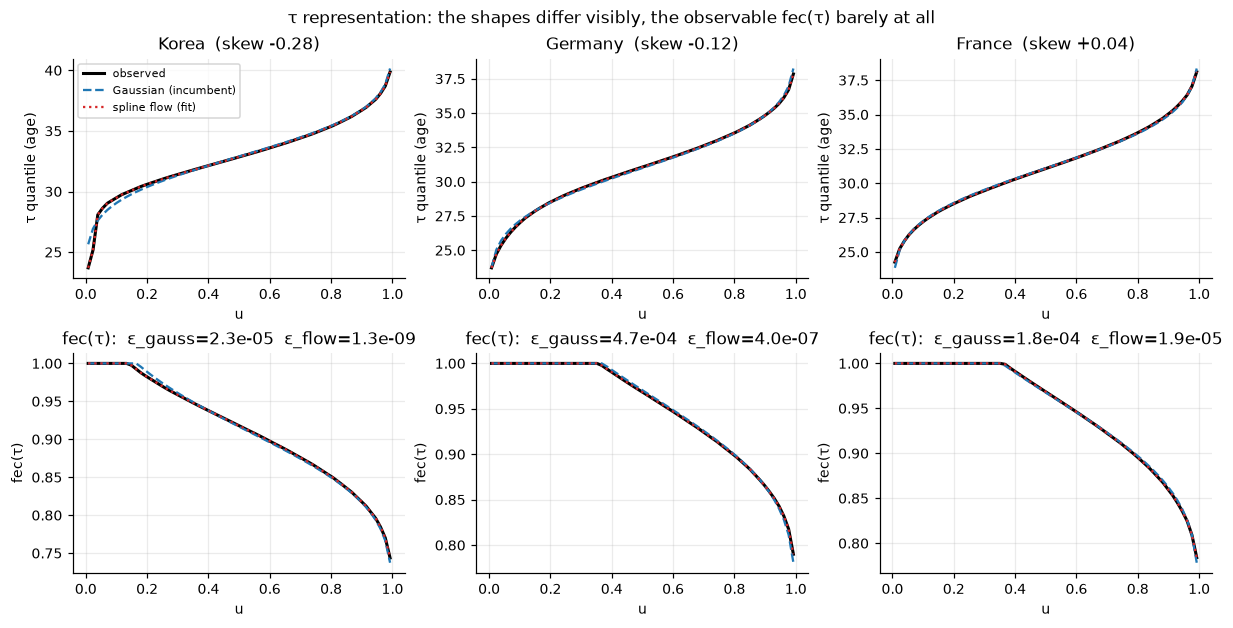

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(11, 5.6), constrained_layout=True)
for j, nm in enumerate(REGIONS):
    r = REPR[nm]
    # top: quantile functions (the shapes)
    ax = axes[0, j]
    ax.plot(u, r["q_obs"], color="k", lw=2, label="observed")
    ax.plot(u, r["gauss"].Qv.numpy(), color="tab:blue", lw=1.5, ls="--", label="Gaussian (incumbent)")
    ax.plot(u, r["flow"].Qv.numpy(), color="tab:red", lw=1.5, ls=":", label="spline flow (fit)")
    ax.set_title(f"{nm}  (skew {OBS[nm]['skew']:+.2f})")
    ax.set_xlabel("u"); ax.set_ylabel("τ quantile (age)")
    if j == 0:
        ax.legend(fontsize=7, loc="upper left")
    # bottom: fec(τ) along the quantile - where the observable is built
    ax = axes[1, j]
    ax.plot(u, fec(r["q_obs"]), color="k", lw=2)
    ax.plot(u, fec(r["gauss"].Qv.numpy()), color="tab:blue", lw=1.5, ls="--")
    ax.plot(u, fec(r["flow"].Qv.numpy()), color="tab:red", lw=1.5, ls=":")
    Gg = [x for x in rows if x["nm"] == nm][0]
    ax.set_title(f"fec(τ):  ε_gauss={Gg['err_g']:.1e}  ε_flow={Gg['err_f']:.1e}")
    ax.set_xlabel("u"); ax.set_ylabel("fec(τ)")
fig.suptitle("τ representation: the shapes differ visibly, the observable fec(τ) barely at all", fontsize=11)
plt.show()

## Verdict - PRUNE #67

**The number that kills it.** The largest faithfulness margin a real-data-fit spline flow buys over the
Gaussian ensemble, on the *only* observable τ feeds TFR through, is **~4e-4 TFR** (Korea; Germany ~5e-4;
France a tie). That margin is:

- **~1000× below** the historical TFR signal a backtest would use (Korea swings ~0.46 TFR/decade), so the
  win is provably unmeasurable - a backtest cannot resolve it
- barely above the **1e-4 calibration tolerance** the Gaussian ensemble already meets - i.e. the incumbent
  already resolves τ finely enough for the model's own precision
- **region-idiosyncratic, not systematic**: France ties, and the observed skew sign is inconsistent (Korea
  **left**-skewed −0.29, Germany −0.12, France +0.05), so the Gaussian introduces no systematic bias for a
  flow to correct

**The premise is refuted by the data.** τ was picked as the widest, most plausibly right-skewed channel, but
the real 2023 schedules for these regions are near-symmetric or left-skewed. The flow's one genuine advantage
- holding skew the Gaussian cannot - has almost nothing to hold. The distribution-level metrics (W2/KS)
favour the flow only because it is fitted to the shape, and even there the gap is a fraction of a year that
collapses to 4e-4 once passed through `fec` and aggregated.

**Both gates assessed honestly.** Gate (a) PASSES - a τ-flow calibrates (degenerate limit is the scalar
exactly; the tiny shape shift re-absorbs into `PB_SCALE`). Gate (b) technically registers a flow win
(ε_flow < ε_gauss for Korea/Germany) but **fails the materiality bar**: the win does not clear the backtest
noise floor and is not systematic across regions.

**Decision.** PRUNE #67. Keep `flow.py` as a differentiable utility (W2, McCann morph, reparameterised
sampling remain useful); do **not** lift the τ core to a fitted `QuantileFlow`. This is a clean null in the
mould of the culture-bearer eigen-operator prune (GOAL-16): the representation is more elegant, but at the
4th decimal of TFR it does not move the numbers.